In [1]:
# Description: This file contains the code to generate the mesh of the RRAM.
import math

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import LinearSegmentedColormap
from scipy.constants import Boltzmann, elementary_charge

In [2]:
# # Definir el tamaño del tablero y los valores del mesh (0 o 1)
# filas, columnas = 100, 100
# mesh = np.random.randint(2, size=(filas, columnas))

# # Crear la figura y los ejes
# fig, ax = plt.subplots()

# color_azul = (0, 0, 0)  # azul
# color_verde = (1, 1, 1)  # verde
# color_borde = (1, 1, 0)  # amarillo
# # Iterar a través de los valores del mesh y agregar cuadrados al gráfico
# for i in range(filas):
#     for j in range(columnas):
#         color = color_azul if mesh[i, j] == 1 else color_verde
#         ax.add_patch(plt.Rectangle((j, i), 0.85, 0.85, color=color))

# # Establecer límites de los ejes y ocultar etiquetas
# ax.set_xlim(-0.75, columnas + 0.5)
# ax.set_ylim(-0.5, filas + 0.5)

# # Major ticks every 20, minor ticks every 5
# major_ticks = np.arange(0, columnas, 1)
# minor_ticks = np.arange(0, columnas, 1)

# # ax.set_xticks(major_ticks)
# ax.set_xticks(minor_ticks, minor=True)
# # ax.set_yticks(major_ticks)
# ax.set_yticks(minor_ticks, minor=True)

# # And a corresponding grid
# ax.grid(which="both")

# # Or if you want different settings for the grids:
# ax.grid(which="minor", alpha=1.00)
# ax.grid(which="major", alpha=0.5)

# plt.show()


# # Mostrar el gráfico
# plt.show()

In [3]:
# Generacion de la vacante

# Constantes


t_0 = 10**13  # Hz, en verdad este es el valor de 1/t_0
E_a = 1  # eV
gamma = 3  # Tiene distintos valores dependiendo si el estado es FORMING/SET y RESET
# Valor de la constante de Boltzmann en eV/K
k_b_ev = Boltzmann / elementary_charge

In [4]:
def generation(
    Delta_t, electric_field, temperature, grid_size=0.25e-9, carga_vacante=2
):
    """
    Calculates the generation rate of a certain process.

    Parameters:
    - Delta_t (float): Time step.
    - electric_field (float): Electric field strength in V/m.
    - temperature (float): Temperature in Kelvin.
    - grid_size (float, optional): Size of the grid in meters. Default is 0.25e-9.
    - carga_vacante (int, optional): Vacancy charge. Default is 2.

    Returns:
    - generation_rate (float): The calculated generation rate.
    """
    # TODO: METERLE REESCALADO PARA INTENTAR ENVITAR TRABAJAR CON NUMEROS TAN GRANDES Y PEQUEÑOS.
    exponente = (E_a - gamma * grid_size * carga_vacante * carga_vacante *
                 elementary_charge * abs(electric_field)) / (k_b_ev * temperature)
    print(f"El campo eléctrico es: {campo_electrico} V/m")
    print(f"El exponente de la probabilidad es: {exponente}")

    return Delta_t * t_0 * (math.exp(-exponente))


d_t = 0.01
campo_electrico = (1) / (10e-9)
temp = 300  # Kelvin

print(
    f"La probablidad de generacion es: {generation(d_t, campo_electrico, temp)}")

El campo eléctrico es: 100000000.0 V/m
El exponente de la probabilidad es: 38.681727071833606
La probablidad de generacion es: 1.5875937562011973e-06


In [5]:
def initial_state(Eje_x, Eje_y, num_trampas):
    # Crear una matriz de ceros de tamaño Eje_x x Eje_y

    InitialState = np.zeros((Eje_x, Eje_y), dtype=int)

    # Generar 5 posiciones aleatorias para los unos

    posiciones_unos = np.random.choice(
        Eje_x * Eje_y, num_trampas, replace=False)

    # Asignar el valor 1 a las posiciones seleccionadas

    for pos in posiciones_unos:
        fila, columna = divmod(pos, Eje_x)
        InitialState[fila, columna] = 1
    return InitialState

In [6]:
mesh = initial_state(5, 5, 10)
print(mesh)

[[0 0 1 0 0]
 [1 1 1 0 1]
 [0 1 0 0 1]
 [0 0 1 1 1]
 [0 0 0 0 0]]


In [7]:
def DifussiveBehaviour(posicion_x: int, Oxigen_Ion_velocity: float, Simulation_time: float, grid_size=0.25e-9):
    vt = Oxigen_Ion_velocity*Simulation_time
    posicion_x = posicion_x*grid_size

    condiciones = [posicion_x <= vt,
                   (vt < posicion_x) and (posicion_x <= vt + grid_size),
                   (vt + grid_size < posicion_x) and (posicion_x <= vt + 3*grid_size),
                   (posicion_x > vt + 3*grid_size)
                   ]

    funciones = [1, 0.3, 0.1, 0]
    return np.piecewise(posicion_x, condiciones, funciones)


print(DifussiveBehaviour(38, 1, 1))

1.0


9.228521458192725e-28
0.025851999786435535


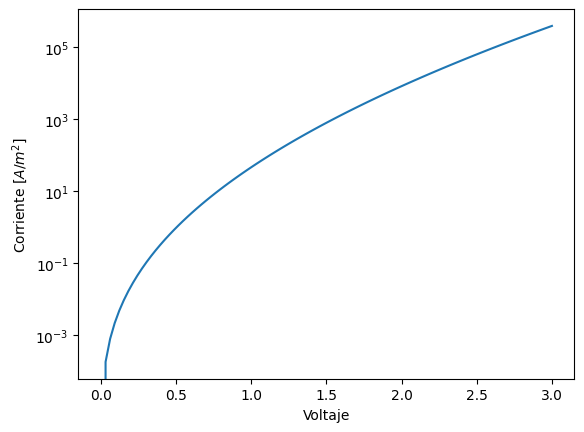

In [8]:
# autopep8: off
import math

import matplotlib.pyplot as plt
import numpy as np

def poole_frenkel(temperature: float, electric_field: np.ndarray,
                  barrera: float = 0.895, beta: float = 2.8E-5, I_0: float = 1e-12) -> np.ndarray:

    k_b_ev = Boltzmann / elementary_charge

    exponencial = np.exp((beta * np.sqrt(electric_field) - barrera) / (k_b_ev * temperature))

    I_poole_frenkel = I_0 * electric_field * exponencial
    return I_poole_frenkel


# Creo el vector de corrientes para cada voltaje
ddp = np.linspace(0, 3, 100)

Voltaje = ddp/10e-9
Corriente = poole_frenkel(300, Voltaje) / (10e-9*10e-9)

print(poole_frenkel(300, 1))
plt.plot(ddp, Corriente)
# nombre de los ejes

plt.xlabel('Voltaje')
# eje logaritmico
plt.yscale('log')
plt.ylabel(r'Corriente $[A/m^2]$')

print((Boltzmann / elementary_charge)*300)

In [9]:
def is_percolation_path(matrix):
    # Check if the matrix is empty
    if not matrix:
        return False

    # Get the dimensions of the matrix
    rows = len(matrix)
    cols = len(matrix[0])

    # Create a visited matrix to keep track of visited nodes
    visited = [[False] * cols for _ in range(rows)]

    # Define the directions for movement: up, down, left, right
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    # Define a helper function for DFS
    def dfs(i, j):
        # Mark the current node as visited
        visited[i][j] = True

        # Check if the current node is at the bottom row
        if i == rows - 1:
            return True

        # Explore the neighbors in the four directions
        for dx, dy in directions:
            ni, nj = i + dx, j + dy

            # Check if the neighbor is within the matrix boundaries and is a valid node
            if 0 <= ni < rows and 0 <= nj < cols and matrix[ni][nj] == 1 and not visited[ni][nj]:
                # Recursively call DFS on the neighbor
                if dfs(ni, nj):
                    return True

        return False

    # Iterate through each node in the first row
    for j in range(cols):
        if matrix[0][j] == 1 and not visited[0][j]:
            # Start DFS from the node in the first row
            if dfs(0, j):
                return True

    return False

In [10]:
matrix = np.zeros((20000, 20000), dtype=int)

for i in range(2000):
    # Genero una posicion aleatoria
    pos_x = np.random.randint(0, 20000)
    pos_y = np.random.randint(0, 20000)

    while matrix[pos_x, pos_y] == 1:
        pos_x = np.random.randint(0, 20000)
        pos_y = np.random.randint(0, 20000)

    matrix[pos_x, pos_y] = 1


print(matrix)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [11]:
x, y = np.meshgrid(np.arange(0, 2000), np.arange(0, 2000))

x_flat = x.flatten()
y_flat = y.flatten()


tuples = list(zip(x_flat, y_flat))

np.random.permutation(tuples)[:200]

array([[ 898, 1707],
       [ 110, 1457],
       [ 135, 1694],
       [ 786, 1833],
       [ 953,  311],
       [1375,  843],
       [1051,  164],
       [1666,  507],
       [1346,  454],
       [1740,  681],
       [1842, 1894],
       [1460,  779],
       [ 275, 1931],
       [  51,  759],
       [1606,  391],
       [ 932,  934],
       [1369, 1732],
       [  16, 1704],
       [1921, 1084],
       [1688,  339],
       [1921,  769],
       [ 578,  449],
       [1484, 1171],
       [1426,  323],
       [1237, 1612],
       [1521, 1776],
       [ 932, 1707],
       [ 319, 1580],
       [ 963, 1696],
       [1873, 1674],
       [  31,  209],
       [1703,  947],
       [ 982, 1304],
       [  83,  185],
       [1620,    9],
       [ 462,  867],
       [ 357, 1735],
       [1994,  142],
       [ 284, 1664],
       [1127, 1481],
       [1469,  641],
       [ 916,  117],
       [1489, 1469],
       [ 536,  444],
       [ 228,  770],
       [1284,  632],
       [1029, 1139],
       [ 329,